In [1]:
from skimage.segmentation import slic
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb
import cv2
import numpy as np
from skimage.measure import regionprops
import functionsTP as myfunc

## SLIC

In [ ]:
image_path = 'images/Image3.jpg'
# image_path = 'images/flair.png'
image = cv2.imread(image_path)
# image = cv2.resize(image, (500,500))

plt.imshow(image)
plt.show()

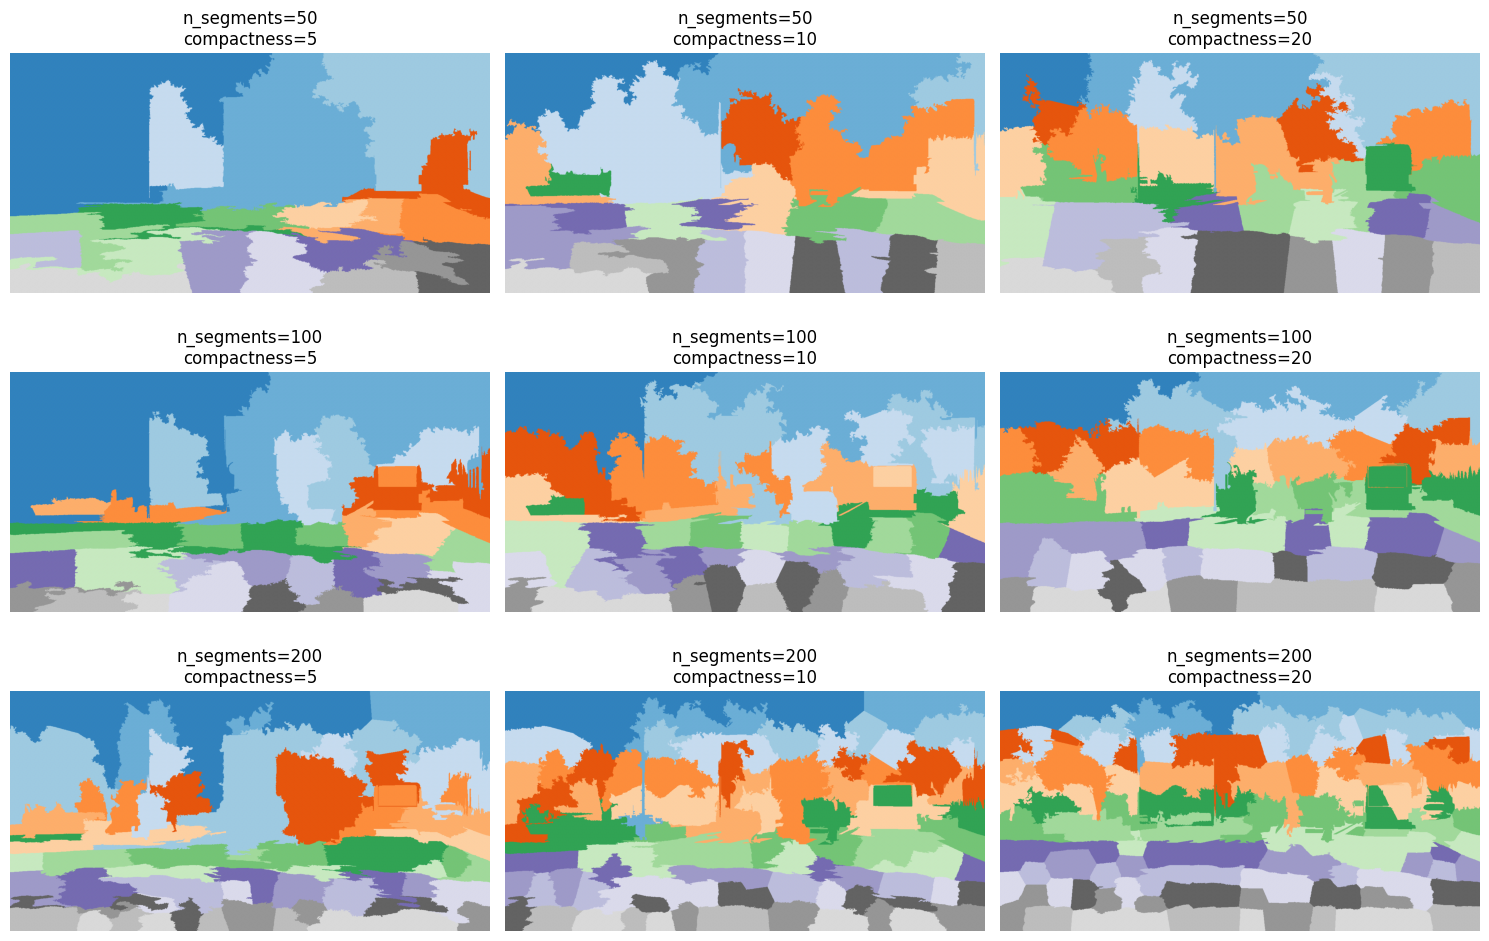

In [3]:
n_seg = [50, 100, 200]
comps = [5, 10, 20]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, n in enumerate(n_seg):
    for j, comp in enumerate(comps):
        segments = slic(image, n_segments=n, compactness=comp)
        
        ax = axs[i, j]
        ax.imshow(segments, cmap='tab20c')
        ax.set_title(f'n_segments={n}\ncompactness={comp}')
        ax.axis('off')

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    SLIC is a method that do not perform well in the street scene example, because objects have very different shapes and sizes and SLIC tends to create regions of similar surface and "squared" forms. Even thought it is controlled with the compactness parameter, it behaves too compact even for low values.
  </p>
</div>

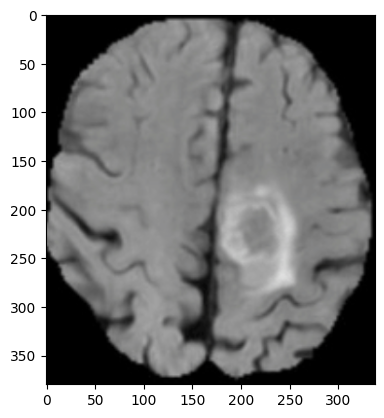

In [6]:
# image_path = 'images/Image3.jpg'
image_path = 'images/flair.png'
image = cv2.imread(image_path)
# image = cv2.resize(image, (500,500))

plt.imshow(image)
plt.show()

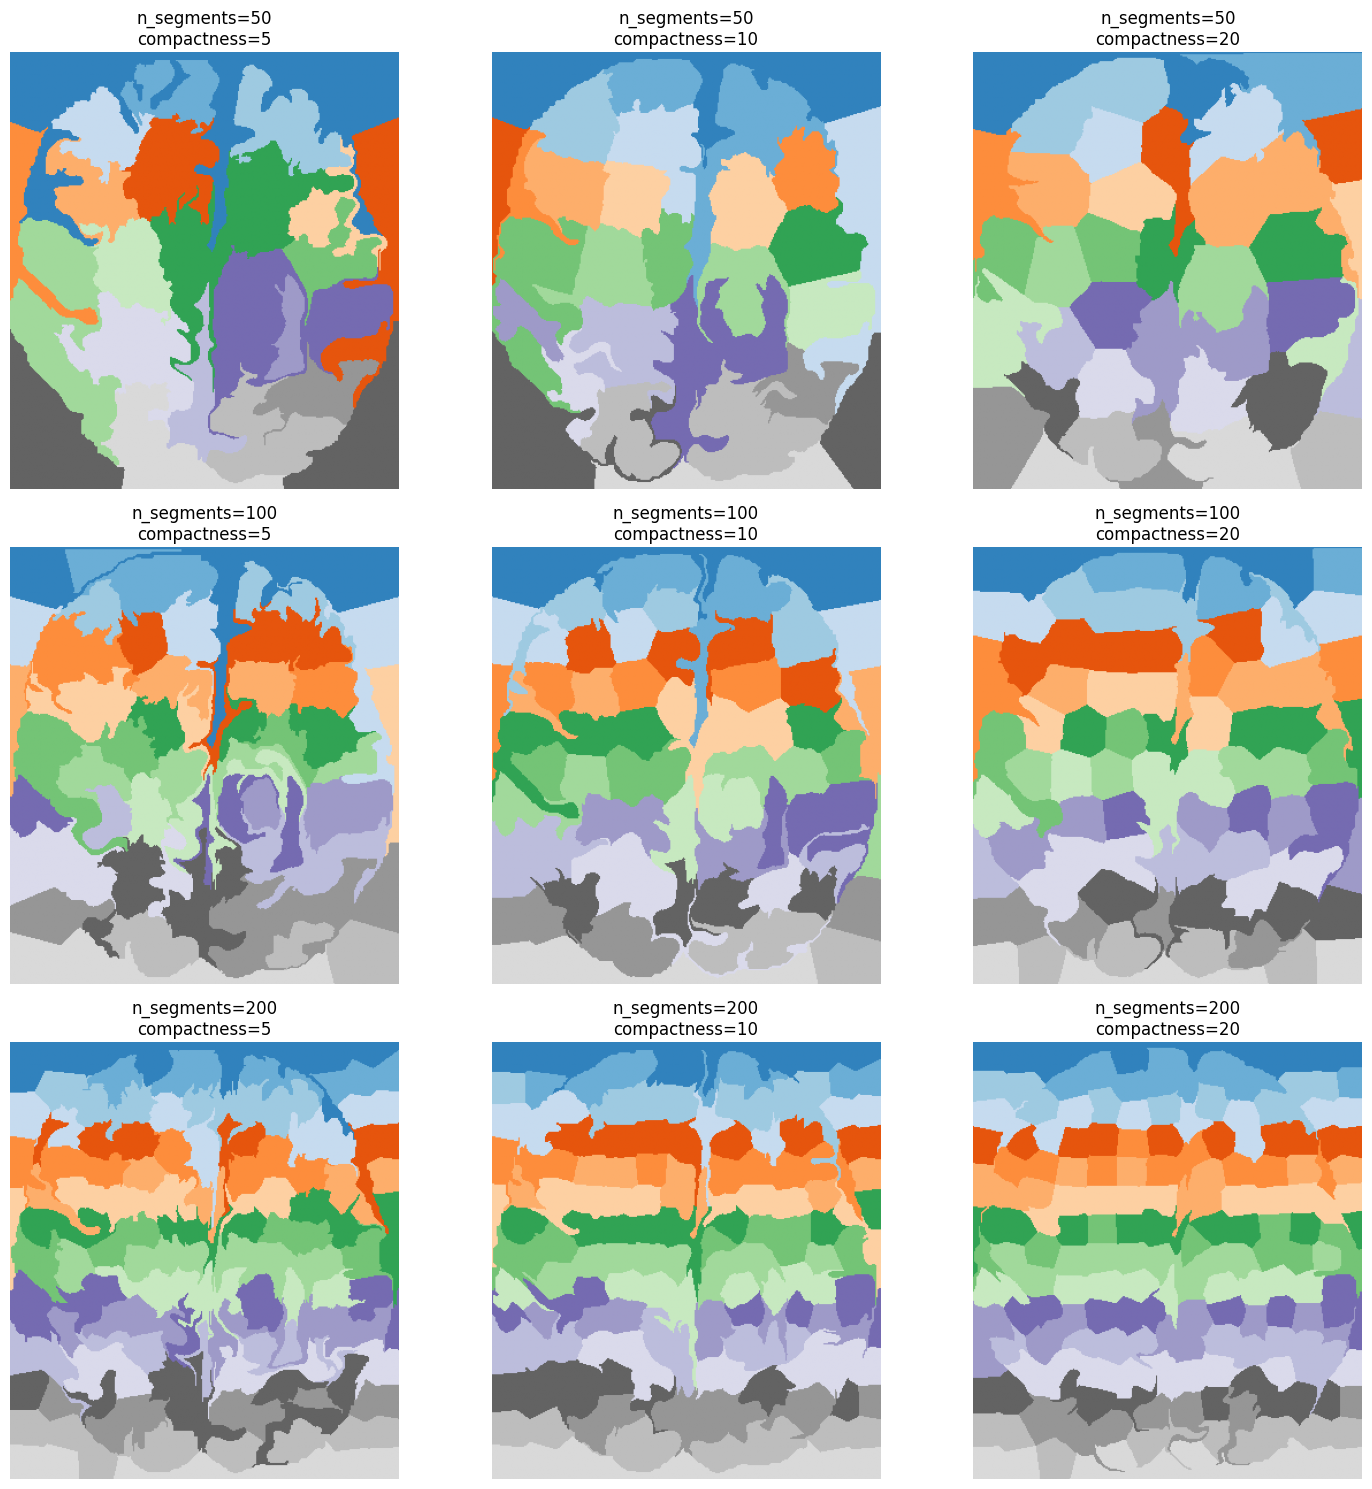

In [7]:
n_seg = [50, 100, 200]
comps = [5, 10, 20]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, n in enumerate(n_seg):
    for j, comp in enumerate(comps):
        segments = slic(image, n_segments=n, compactness=comp)
        
        ax = axs[i, j]
        ax.imshow(segments, cmap='tab20c')
        ax.set_title(f'n_segments={n}\ncompactness={comp}')
        ax.axis('off')

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Now, for this medical image scenario, SLIC has a much better performance. Testing different hyperparameter combinations we can see that the target region is more distinguishble with 100 segments and compactness=5. This allows us to segment the region in many individual parts, SLIC probably can be used together with a grey level measurement approach to clearly which regions should be unified to define the final segmentation with all the interest zone segmented into one.
  </p>
</div>

## Felzenszwalb

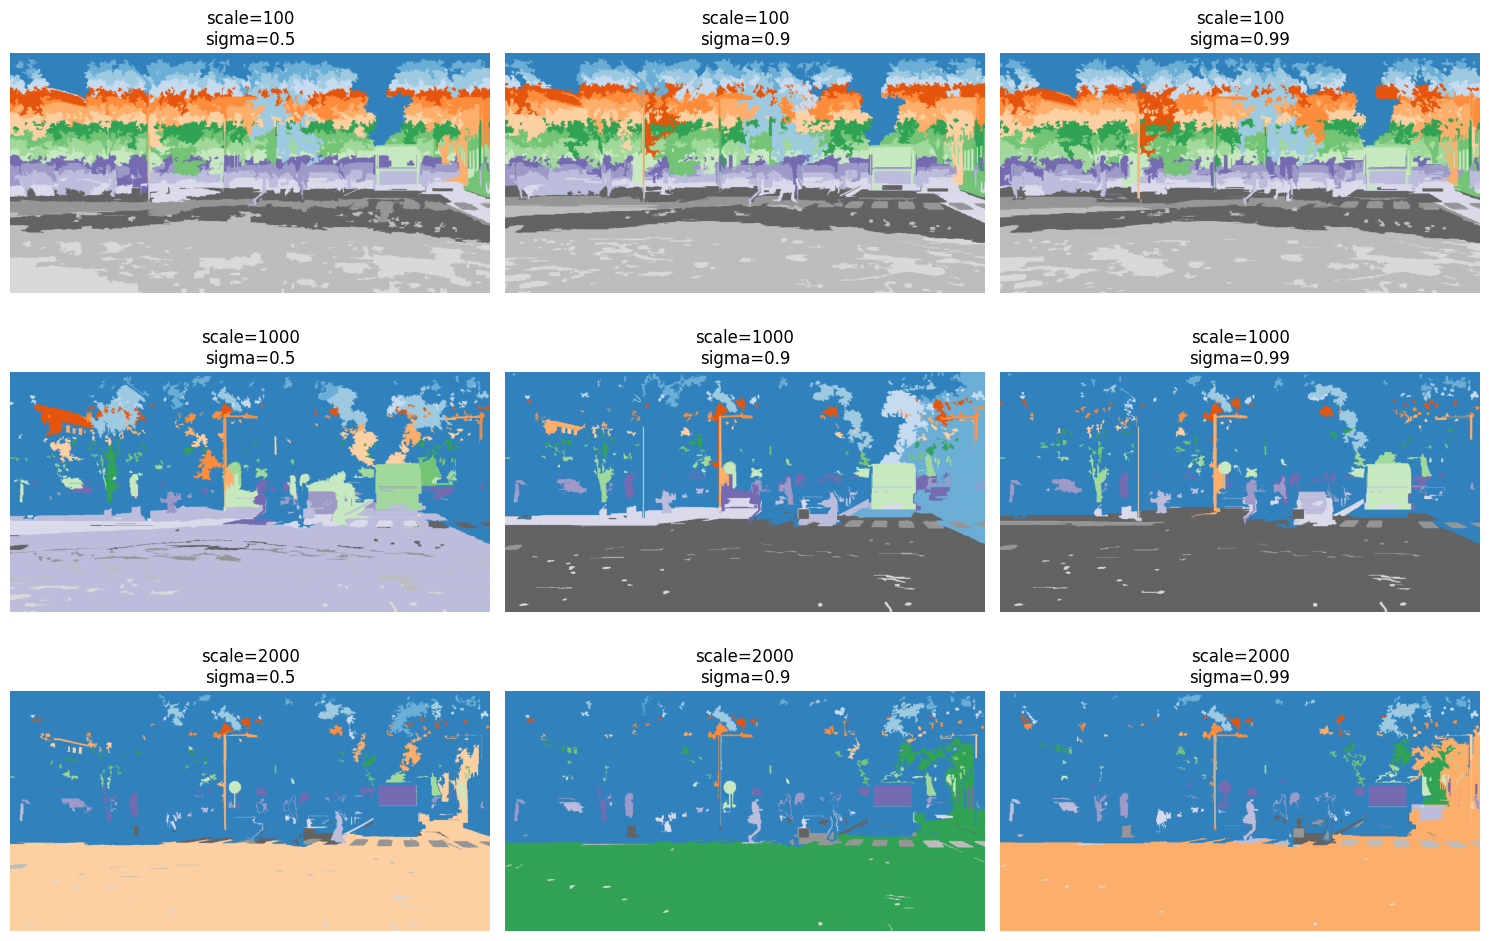

In [4]:
scales = [100, 1000, 2000]
sigmas = [0.5, 0.9, 0.99]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, scale in enumerate(scales):
    for j, sigma in enumerate(sigmas):
        segments = felzenszwalb(image, scale=scale, sigma=sigma, min_size=50)
        
        ax = axs[i, j]
        ax.imshow(segments, cmap='tab20c')
        ax.set_title(f'scale={scale}\nsigma={sigma}')
        ax.axis('off')

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Differently than SLIC, the feltzenszwalb methed performed well in the street scene with the right parameters. The scale parameter has a major effect, low values cause over segmentation of objetes in the scene, only high scale values are able to correcly segment the entire street into a single area and also most of the background and people. The sigma has a fine tuning effect, helping with segmentation of small objets.
  </p>
</div>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


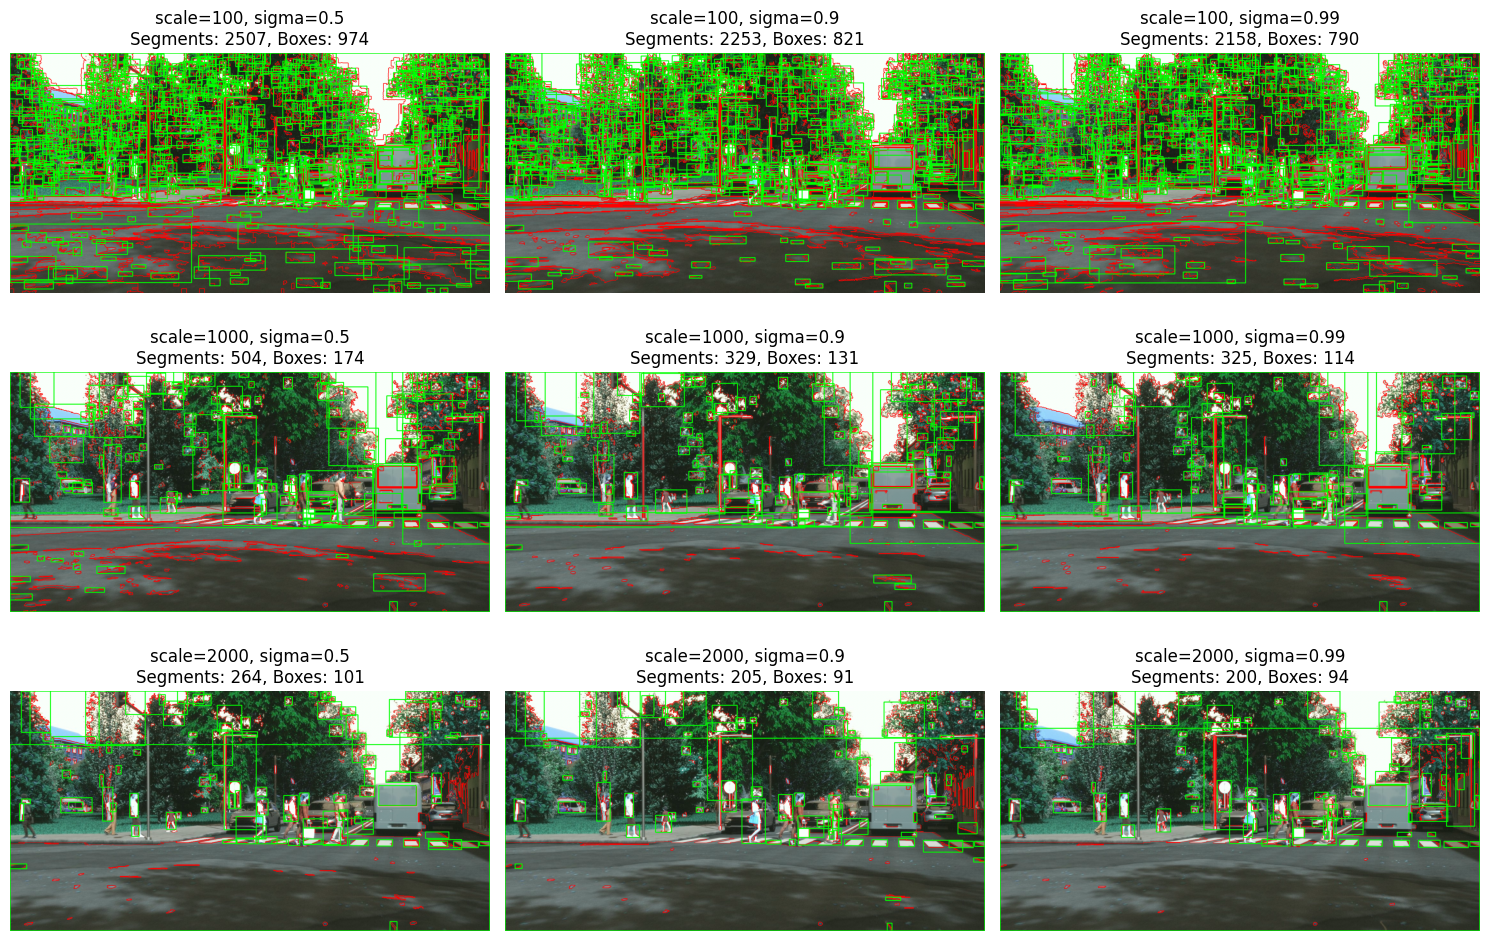

In [5]:
image_rgb = image if len(image.shape) == 3 else cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

scales = [100, 1000, 2000]
sigmas = [0.5, 0.9, 0.99]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, scale in enumerate(scales):
    for j, sigma in enumerate(sigmas):
        segments = felzenszwalb(image, scale=scale, sigma=sigma, min_size=50)
        
        boxes = myfunc.generate_bounding_boxes(segments)
    
        final_boxes = myfunc.non_max_suppression(boxes, overlap_thresh=0.3)
        
        ax = axs[i, j]
        
        overlay = image_rgb.copy()
        
        from skimage.segmentation import mark_boundaries
        if len(image.shape) == 3:
            overlay = mark_boundaries(overlay, segments, color=(1, 0, 0), mode='outer')
        
        for box in final_boxes:
            xmin, ymin, xmax, ymax, _ = box.astype(int)
            cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        
        ax.imshow(overlay)
        ax.set_title(f'scale={scale}, sigma={sigma}\nSegments: {len(np.unique(segments))}, Boxes: {len(final_boxes)}')
        ax.axis('off')
        
        print()

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The over segmented results with low scale values caused the creation of many unecessary boxes. The better segmented examples with high scale presented a more reasonable box placement, but with some incorecly placed boxes mostly on threes, because of the confusing regions they generate. Sigma helps with the correct boxing of people and street objects.  
  </p>
</div>